# Stable Diffusion v1.5 Playground

Generate images from text prompts using the same SD v1.5 model used in `SDSLoss`.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

device = torch.device("cpu") # 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

/home/hamid/miniconda3/envs/infidictionary/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Load model

In [2]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
)
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=True)
print("Pipeline ready.")

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 11935.01it/s].25it/s]
CLIPTextModel LOAD REPORT from: /home/hamid/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 2035.77it/s]
StableDiffusionSafetyChecker LOAD REPORT from: /home/hamid/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Not

Pipeline ready.


## Settings

In [6]:
# PROMPT          = "A painting in the style of Vincent Van Gogh"
PROMPT         = "Joseph Fourier's Face, Colorful"
NEGATIVE_PROMPT = ""           # leave empty to disable
N_IMAGES        = 4            # number of samples
GUIDANCE_SCALE  = 50 # 7.5          # CFG scale (7.5 is SD default; try 50 to match SDSLoss)
N_STEPS         = 50           # denoising steps
SEED            = None         # set an int for reproducibility, None for random

## Generate

In [7]:
generator = torch.Generator(device=device).manual_seed(SEED) if SEED is not None else None

with torch.inference_mode():
    result = pipe(
        prompt=[PROMPT] * N_IMAGES,
        negative_prompt=[NEGATIVE_PROMPT] * N_IMAGES if NEGATIVE_PROMPT else None,
        guidance_scale=GUIDANCE_SCALE,
        num_inference_steps=N_STEPS,
        generator=generator,
    )

images = result.images  # list of PIL images
print(f"Generated {len(images)} images.")

Generated 4 images.


## Visualise

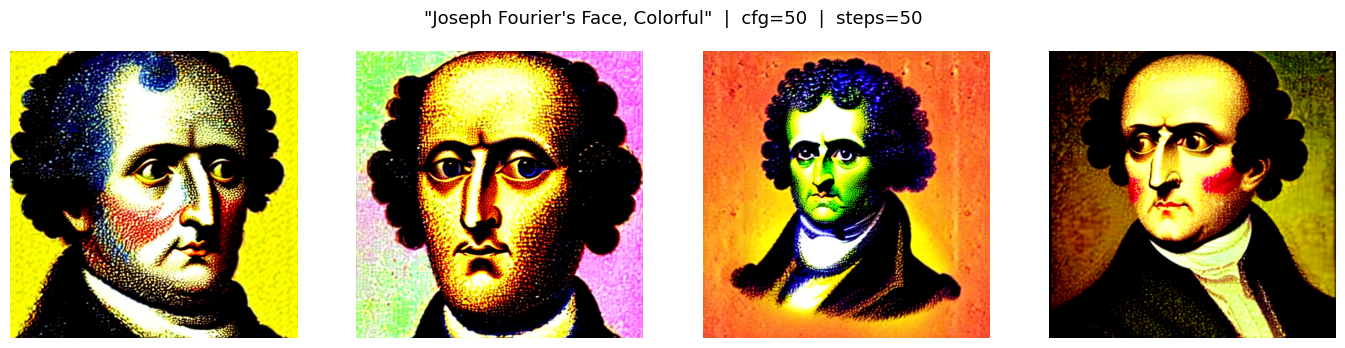

In [8]:
N_COLS = min(4, N_IMAGES)
N_ROWS = (N_IMAGES + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 3.5, N_ROWS * 3.5))
axes = np.array(axes).flatten()

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")
for ax in axes[len(images):]:
    ax.axis("off")

fig.suptitle(
    f'"{PROMPT}"  |  cfg={GUIDANCE_SCALE}  |  steps={N_STEPS}',
    fontsize=13,
)
plt.tight_layout()
plt.show()